In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib
import os

In [4]:
cases = pd.read_csv(
    "../data/synthetic/missing_person_cases.csv"
)

print("Dataset shape:", cases.shape)
cases.head()

Dataset shape: (100, 15)


,Case_ID,Person_ID,Age_Group,Gender,Last_Latitude,Last_Longitude,Last_Seen_Time,Day,Weather,Usual_Area,Average_Distance,Average_Speed,Previous_Area,Time_Since_Last_Seen,Target_Area
0,MP-2026-001,P001,36-45,Male,39.980525,116.449440,2008-10-12 08:38:24,Sunday,Rain,9,0.003579,6.441649,9,3,9
1,MP-2026-002,P002,46-60,Male,39.968322,116.421253,2009-06-04 06:21:42,Thursday,Clear,9,0.010934,39.361368,9,2,9
2,MP-2026-003,P003,36-45,Not Specified,40.024186,116.435575,2011-12-26 08:38:20,Monday,Rain,9,0.000613,2.205271,9,3,9
3,MP-2026-004,P004,46-60,Male,37.914902,112.147270,2009-01-27 05:59:54,Tuesday,Rain,6,0.039915,35.923149,6,8,6
4,MP-2026-005,P005,18-25,Female,39.981445,116.326191,2009-09-18 19:17:36,Friday,Cloudy,9,0.000949,1.707791,9,8,9


In [5]:
cases["Last_Seen_Time"] = pd.to_datetime(
    cases["Last_Seen_Time"],
    errors="coerce"
)

cases["Hour"] = cases[
    "Last_Seen_Time"
].dt.hour

print("Time conversion completed!")

Time conversion completed!


In [6]:
print(
    cases["Target_Area"].value_counts()
)

Target_Area
9    59
1    29
0     3
6     2
7     2
2     2
3     1
5     1
4     1
Name: count, dtype: int64


In [7]:
features = [
    "Age_Group",
    "Day",
    "Weather",
    "Last_Latitude",
    "Last_Longitude",
    "Average_Distance",
    "Average_Speed",
    "Previous_Area",
    "Usual_Area",
    "Time_Since_Last_Seen",
    "Hour"
]

X = cases[features].copy()

y = cases["Target_Area"].copy()

print("Input shape:", X.shape)

Input shape: (100, 11)


In [8]:
X = pd.get_dummies(
    X,
    columns=[
        "Age_Group",
        "Day",
        "Weather"
    ],
    dtype=int
)

print("Final feature count:", X.shape[1])

Final feature count: 22


In [9]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print("Target areas:")
print(target_encoder.classes_)

Target areas:
[0 1 2 3 4 5 6 7 9]


In [10]:
target_counts = pd.Series(
    y_encoded
).value_counts()

print(target_counts)

8    59
1    29
0     3
6     2
7     2
2     2
3     1
5     1
4     1
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 80
Testing: 20


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=2
)

rf_model.fit(
    X_train,
    y_train
)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total num

In [15]:
y_pred = rf_model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [16]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9
Precision: 0.86
Recall   : 0.9
F1 Score : 0.8778


In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 4  0  0  0  0]
 [ 0  0  0  0  0]
 [ 1  0  0  0  0]
 [ 0  1  0  0  0]
 [ 0  0  0  0 14]]


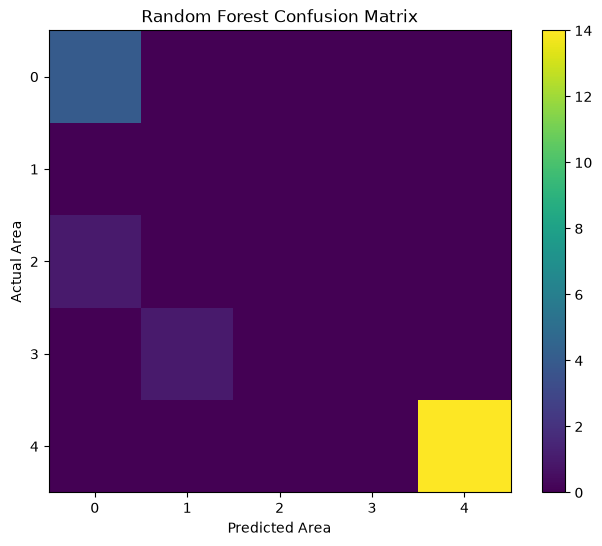

In [18]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xlabel("Predicted Area")
plt.ylabel("Actual Area")
plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.show()

In [19]:
probabilities = rf_model.predict_proba(
    X_test
)

print(
    "Probability shape:",
    probabilities.shape
)

Probability shape: (20, 7)


In [20]:
top1_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Top-1 Accuracy:",
    round(top1_accuracy, 4)
)

Top-1 Accuracy: 0.9


In [21]:
top3_correct = 0

for actual, probs in zip(
    y_test,
    probabilities
):
    
    top3 = np.argsort(probs)[-3:]
    
    if actual in top3:
        top3_correct += 1

top3_accuracy = (
    top3_correct / len(y_test)
)

print(
    "Top-3 Accuracy:",
    round(top3_accuracy, 4)
)

Top-3 Accuracy: 0.25


In [22]:
top5_correct = 0

for actual, probs in zip(
    y_test,
    probabilities
):
    
    top5 = np.argsort(probs)[-5:]
    
    if actual in top5:
        top5_correct += 1

top5_accuracy = (
    top5_correct / len(y_test)
)

print(
    "Top-5 Accuracy:",
    round(top5_accuracy, 4)
)

Top-5 Accuracy: 0.25


In [23]:
evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Top-1 Accuracy",
        "Top-3 Accuracy",
        "Top-5 Accuracy"
    ],
    
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        top1_accuracy,
        top3_accuracy,
        top5_accuracy
    ]
})

evaluation

,Metric,Score
0,Accuracy,0.900000
1,Precision,0.860000
2,Recall,0.900000
3,F1 Score,0.877778
4,Top-1 Accuracy,0.900000
5,Top-3 Accuracy,0.250000
6,Top-5 Accuracy,0.250000


In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
4,Previous_Area,0.282705
5,Usual_Area,0.251168
0,Last_Latitude,0.215328
2,Average_Distance,0.053935
1,Last_Longitude,0.053421
3,Average_Speed,0.042071
7,Hour,0.018008
6,Time_Since_Last_Seen,0.012602
18,Day_Wednesday,0.011372
20,Weather_Cloudy,0.009517


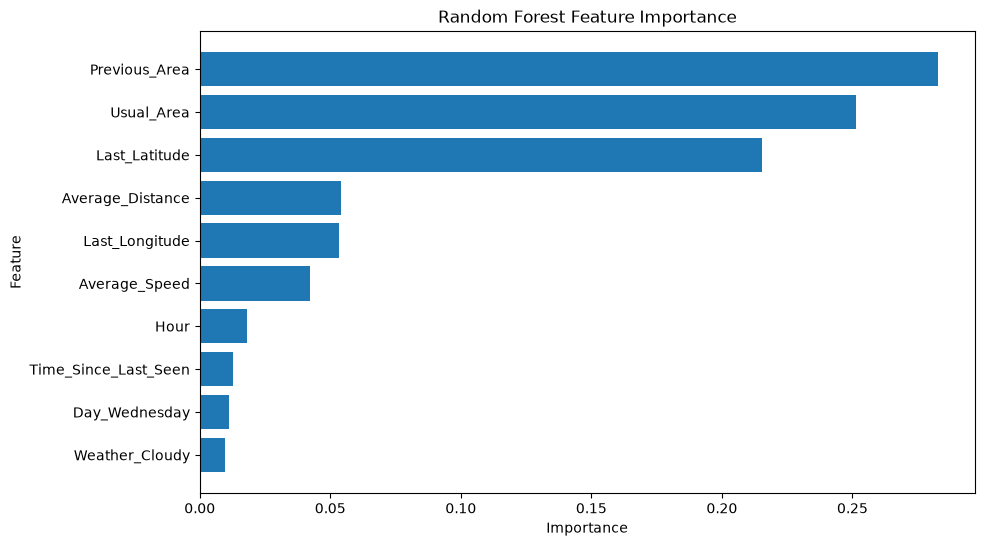

In [25]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [26]:
evaluation.to_csv(
    "../data/processed/location_model_evaluation.csv",
    index=False
)

feature_importance.to_csv(
    "../data/processed/location_feature_importance.csv",
    index=False
)

print("Evaluation results saved!")

Evaluation results saved!


In [27]:
import os
import joblib

os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    rf_model,
    "../models/location_model.pkl"
)

joblib.dump(
    target_encoder,
    "../models/target_encoder.pkl"
)

joblib.dump(
    list(X.columns),
    "../models/location_features.pkl"
)

print("Location model saved successfully!")

Location model saved successfully!


In [28]:
print("========== LOCATION PREDICTION RESULTS ==========")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print(
    "Top-1 Accuracy:",
    round(top1_accuracy, 4)
)

print(
    "Top-3 Accuracy:",
    round(top3_accuracy, 4)
)

print(
    "Top-5 Accuracy:",
    round(top5_accuracy, 4)
)

print("\nModel saved successfully!")

========== LOCATION PREDICTION RESULTS ==========
Accuracy : 0.9
Precision: 0.86
Recall   : 0.9
F1 Score : 0.8778
Top-1 Accuracy: 0.9
Top-3 Accuracy: 0.25
Top-5 Accuracy: 0.25

Model saved successfully!
